# Dark Pattern Detector — Notebook 3: Deep Learning & the Honest Comparison

**Goal:** put three models on the *same* leak-free test set and see who actually wins.

Notebook 2 reported a macro-F1 of ~0.94, but that number came from a plain random split.
A lot of our training rows are templated (same sentence, different brand or price), so a
random split quietly drops template *siblings* into both train and test — the model gets to
peek at the answer. Before trusting any score we re-ran the split properly
(`src/leak_audit.py`): partition by template skeleton so no template lands on both sides.

On that honest split the classical model falls to ~0.64. This notebook takes that as the
real starting line and asks: **can a model that actually reads the phrasing do better?**

Steps:
1. load the features + the leak-free split indices from the audit.
2. re-establish the classical baseline on the honest split (our reference).
3. train a from-scratch LSTM — the documented experiment we expect to *lose*.
4. fine-tune DistilBERT — the headline model (gated; flip `RUN_BERT` to train it).
5. evaluate everyone on the same test split **and** on 23 real Indian rows (OOD).
6. one comparison table + an error-analysis look at what still confuses each model.

## 0. Colab Setup (skip if running locally)

On Colab the repo isn't here yet and the working directory is `/content`, so we clone the
project and `cd` into `notebooks/` — that way every `../data/...` and `../reports/...` path
in this notebook resolves exactly as it does locally. We also pull the NLTK data the feature
code needs and make sure `transformers` is present. The cell is a no-op off Colab.

In [1]:
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    REPO = 'https://github.com/goyashek/dark-pattern-detector.git'
    if not os.path.isdir('/content/dark-pattern-detector'):
        os.system(f'git clone {REPO} /content/dark-pattern-detector')
    os.chdir('/content/dark-pattern-detector/notebooks')
    os.system('pip -q install transformers')
    print('cwd:', os.getcwd())

# NLTK data needed by clean_and_lemmatize / extract_features (section 8).
# Already present locally; fresh on Colab. Guarded so it's quick when cached.
import nltk
for pkg, path in [('punkt', 'tokenizers/punkt'),
                  ('punkt_tab', 'tokenizers/punkt_tab'),
                  ('wordnet', 'corpora/wordnet'),
                  ('omw-1.4', 'corpora/omw-1.4'),
                  ('averaged_perceptron_tagger', 'taggers/averaged_perceptron_tagger'),
                  ('averaged_perceptron_tagger_eng', 'taggers/averaged_perceptron_tagger_eng')]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)
print('nltk data ready')

nltk data ready


## 1. Import Libraries

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler, PowerTransformer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
np.random.seed(SEED)

# we collect every model's scores here so the final table is just a render of this dict
results = {}

## 2. Load Features and the Leak-Free Split

`features.csv` is exactly what Notebook 1 produced. The new part is
`reports/leak_free_split.json` — the train/test **row indices** from the leak audit. Every
model below reads these same indices, so nobody gets an easier test set than anyone else.

In [3]:
df = pd.read_csv('../data/processed/features.csv')
# same NaN guard as NB2: a few rows lemmatise to an empty clean_text (read back as NaN)
df['clean_text'] = df['clean_text'].fillna('')

with open('../reports/leak_free_split.json') as f:
    split = json.load(f)
train_idx = np.array(split['train'])
test_idx  = np.array(split['test'])

print('rows:', len(df), '| train:', len(train_idx), '| test:', len(test_idx))
df['Pattern Category'].value_counts()

rows: 3896 | train: 3012 | test: 884


Pattern Category
Not a Dark Pattern         1218
Interface Interference      382
False Urgency               360
Disguised Advertisement     270
Nagging                     246
Bait and Switch             217
Basket Sneaking             199
Confirm Shaming             184
Trick Question              165
Forced Action               159
Subscription Trap           156
Drip Pricing                134
SaaS Billing                118
Rogue Malware                88
Name: count, dtype: int64

## 3. The Leak Audit in One Picture

Quick recap of *why* we switched splits, straight from `reports/leak_audit.json`. The naive
split's score is inflated because template siblings leak across it; the honest split removes
that. Same tuned pipeline from NB2, two different splits.

naive split  : 312/780 test rows (40.0%) had a template twin in train
leak-free    : 0 leaked rows (clean)



,naive (optimistic),leak-free (honest)
Linear SVC,0.939,0.607
XGBoost,0.945,0.639


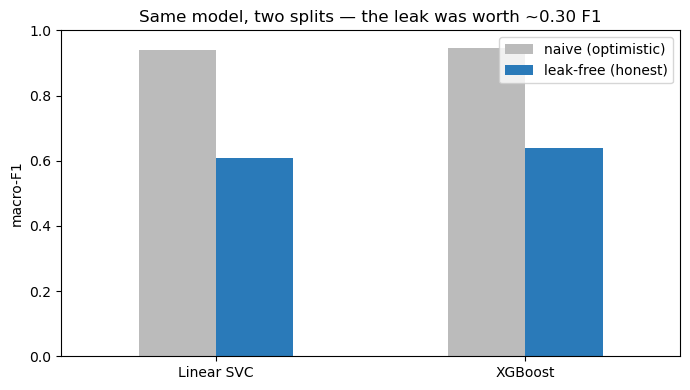

In [4]:
with open('../reports/leak_audit.json') as f:
    audit = json.load(f)

naive = audit['naive_split']
mdl = audit['models']
print(f"naive split  : {naive['leaked_test_rows']}/{naive['test_size']} test rows "
      f"({naive['leaked_test_pct']}%) had a template twin in train")
print(f"leak-free    : {audit['leak_free_split']['leaked_test_rows']} leaked rows (clean)\n")

inflation = pd.DataFrame({
    'naive (optimistic)':  {k: v['macro_f1_naive']    for k, v in mdl.items()},
    'leak-free (honest)':  {k: v['macro_f1_leakfree'] for k, v in mdl.items()},
}).rename(index={'svc': 'Linear SVC', 'xgb': 'XGBoost'})
display(inflation.round(3))

ax = inflation.plot(kind='bar', figsize=(7, 4), color=['#bbb', '#2a7ab9'], rot=0)
ax.set_ylabel('macro-F1'); ax.set_title('Same model, two splits — the leak was worth ~0.30 F1')
ax.set_ylim(0, 1); plt.tight_layout(); plt.show()

## 4. Targets, Columns and a Shared Scoreboard

We encode the 14 category names to integers once and reuse the encoder everywhere so the
LSTM, DistilBERT and the classical model all speak the same label ids. `evaluate()` is the
single scoring function every model gets graded by — macro-F1 first, because the classes are
imbalanced and we care about the rare ones.

In [5]:
num_cols = [
    "urgency_kw_count", "scarcity_kw_count", "shame_phrase_flag", "cancel_diff_score",
    "social_proof_flag", "price_drip_flag", "discount_claim_flag", "neg_option_flag",
    "all_caps_ratio", "exclamation_count", "question_count", "text_length", "word_count",
    "number_present", "time_reference_flag", "noun_ratio", "verb_ratio", "adj_ratio",
    "adv_ratio", "sentiment_polarity", "sentiment_subjectivity", "avg_word_len",
]

le = LabelEncoder()
y_all = le.fit_transform(df['Pattern Category'])
CLASSES = list(le.classes_)
n_classes = len(CLASSES)

# text-only views (for the deep models) and the full feature view (for classical)
text_train, text_test = df['text'].iloc[train_idx].tolist(), df['text'].iloc[test_idx].tolist()
y_train, y_test = y_all[train_idx], y_all[test_idx]

def evaluate(name, y_true, y_pred, store=True):
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    if store:
        results.setdefault(name, {})['macro_f1'] = round(float(f1), 4)
        results[name]['accuracy'] = round(float(acc), 4)
    print(f"{name:24s} macro-F1={f1:.4f}  accuracy={acc:.4f}")
    return f1, acc

## 5. Classical Baseline on the Honest Split

Same pipeline as Notebook 2 (TF-IDF 1–3grams + the 22 numeric features → SMOTE → classifier)
with the tuned params Optuna found. The only change is *which rows* are in train vs test. This
is our reference line — anything fancier has to beat ~0.64 to earn its place.

In [6]:
X_full = df[['clean_text'] + num_cols]
X_train_c, X_test_c = X_full.iloc[train_idx], X_full.iloc[test_idx]

preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=300, ngram_range=(1, 3), min_df=2, sublinear_tf=True), 'clean_text'),
    ('num', Pipeline([('scale', RobustScaler()), ('power', PowerTransformer(method='yeo-johnson'))]), num_cols),
])

# tuned params lifted from NB2's Optuna study
clf_models = {
    'Classical (SVC)': LinearSVC(C=2.1243, loss='squared_hinge', class_weight='balanced',
                                 random_state=SEED, max_iter=5000),
    'Classical (XGB)': XGBClassifier(n_estimators=105, max_depth=9, learning_rate=0.20397,
                                     subsample=0.7637, colsample_bytree=0.7545,
                                     eval_metric='mlogloss', random_state=SEED, tree_method='hist'),
}
classical_pipes = {}
for name, clf in clf_models.items():
    pipe = ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=SEED)), ('clf', clf)])
    pipe.fit(X_train_c, y_train)
    classical_pipes[name] = pipe
    evaluate(name, y_test, pipe.predict(X_test_c))

Classical (SVC)          macro-F1=0.6042  accuracy=0.7296


Classical (XGB)          macro-F1=0.6387  accuracy=0.7353


## 6. A From-Scratch LSTM

Now the experiment we *expect* to underperform, documented honestly. The idea: skip the
hand-built features entirely and let a small recurrent net learn from the raw word sequence.
We build our own vocabulary, turn each row into a sequence of token ids, pad to a fixed
length, and train an embedding → LSTM → linear classifier.

Why we expect it to struggle: our rows are short and our dataset is small (~3k rows). LSTMs
trained from scratch are data-hungry and have no outside knowledge of language — every word
meaning has to be learned from these few examples. We give it `class_weight` to fight the
imbalance, but this is the honest "we tried it, here's why it lost" rung of the ladder.

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter

torch.manual_seed(SEED)
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def tokenize(t):
    import re
    return re.findall(r"[a-z0-9₹$%]+|[!?]", str(t).lower())

# vocab from TRAIN ONLY (test words map to <unk> — no peeking)
counter = Counter(tok for t in text_train for tok in tokenize(t))
itos = ['<pad>', '<unk>'] + [w for w, c in counter.items() if c >= 2]
stoi = {w: i for i, w in enumerate(itos)}
MAXLEN = 40

def encode(texts):
    seqs = []
    for t in texts:
        ids = [stoi.get(tok, 1) for tok in tokenize(t)][:MAXLEN]
        ids += [0] * (MAXLEN - len(ids))
        seqs.append(ids)
    return torch.tensor(seqs, dtype=torch.long)

Xtr, Xte = encode(text_train), encode(text_test)
ytr_t = torch.tensor(y_train, dtype=torch.long)
print('vocab size:', len(itos))

device: mps
vocab size: 1601


In [8]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab, emb=64, hid=64, n_cls=14):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hid * 2, n_cls)
    def forward(self, x):
        e = self.emb(x)
        out, _ = self.lstm(e)
        pooled = out.max(dim=1).values          # max-pool over time
        return self.fc(self.drop(pooled))

# class weights to counter imbalance (same spirit as class_weight='balanced')
counts = np.bincount(y_train, minlength=n_classes)
weights = torch.tensor(counts.sum() / (n_classes * np.maximum(counts, 1)), dtype=torch.float32).to(device)

model = LSTMClassifier(len(itos), n_cls=n_classes).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss(weight=weights)
loader = DataLoader(TensorDataset(Xtr, ytr_t), batch_size=32, shuffle=True)

EPOCHS = 12
for ep in range(1, EPOCHS + 1):
    model.train(); tot = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward(); opt.step()
        tot += loss.item() * len(xb)
    if ep % 3 == 0 or ep == 1:
        print(f"epoch {ep:2d}  train loss {tot/len(Xtr):.4f}")

model.eval()
with torch.no_grad():
    lstm_pred = model(Xte.to(device)).argmax(1).cpu().numpy()
evaluate('LSTM (from scratch)', y_test, lstm_pred)

epoch  1  train loss 1.9772


epoch  3  train loss 0.2781


epoch  6  train loss 0.1074


epoch  9  train loss 0.0540


epoch 12  train loss 0.0324


LSTM (from scratch)      macro-F1=0.5404  accuracy=0.6742


(0.5403537081478382, 0.6742081447963801)

## 7. Fine-Tuned DistilBERT (the headline model)

DistilBERT already knows English — it was pre-trained on a huge corpus, so it starts with a
real understanding of phrasing instead of learning words from our 3k rows. We **fine-tune**
it (not freeze it): a classification head on top, and we let the whole model's weights adjust
to our 14 classes. This is the step that should finally beat the classical baseline, because
the win comes from understanding *wording* ("cancel anytime*" vs "to cancel, call our
hotline"), which is exactly what bag-of-ngrams misses.

> **This cell is gated.** Fine-tuning is the slow step (minutes on CPU/MPS, no CUDA here), so
> it does not run on a plain notebook execute. Flip `RUN_BERT = True` and run this cell when
> you're ready. It saves predictions to `results['DistilBERT']`, so the comparison table
> below fills in automatically once it's done.

In [9]:
RUN_BERT = False   # <-- flip to True to fine-tune (slow on CPU/MPS)

if RUN_BERT:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from torch.utils.data import DataLoader, TensorDataset

    CKPT = 'distilbert-base-uncased'
    tok = AutoTokenizer.from_pretrained(CKPT)

    def bert_encode(texts):
        enc = tok(list(texts), truncation=True, padding='max_length', max_length=64, return_tensors='pt')
        return enc['input_ids'], enc['attention_mask']

    tr_ids, tr_mask = bert_encode(text_train)
    te_ids, te_mask = bert_encode(text_test)
    bert = AutoModelForSequenceClassification.from_pretrained(CKPT, num_labels=n_classes).to(device)

    opt_b = torch.optim.AdamW(bert.parameters(), lr=3e-5)
    loss_b = nn.CrossEntropyLoss(weight=weights)
    dl = DataLoader(TensorDataset(tr_ids, tr_mask, ytr_t), batch_size=16, shuffle=True)

    BERT_EPOCHS = 4
    for ep in range(1, BERT_EPOCHS + 1):
        bert.train(); tot = 0
        for ids, mask, yb in dl:
            ids, mask, yb = ids.to(device), mask.to(device), yb.to(device)
            opt_b.zero_grad()
            out = bert(input_ids=ids, attention_mask=mask).logits
            l = loss_b(out, yb); l.backward(); opt_b.step()
            tot += l.item() * len(ids)
        print(f"epoch {ep}  train loss {tot/len(tr_ids):.4f}")

    bert.eval()
    with torch.no_grad():
        bert_pred = bert(input_ids=te_ids.to(device),
                         attention_mask=te_mask.to(device)).logits.argmax(1).cpu().numpy()
    evaluate('DistilBERT', y_test, bert_pred)

    # stash for OOD + saving later
    globals()['bert'], globals()['tok'], globals()['bert_pred'] = bert, tok, bert_pred
else:
    print("DistilBERT cell is gated (RUN_BERT=False). Flip it to True to fine-tune.")

DistilBERT cell is gated (RUN_BERT=False). Flip it to True to fine-tune.


## 8. The Real Test — 23 Indian Rows It Has Never Seen (OOD)

Everything above is still our own data. The honest stress test is `ood_real_test.csv`: 23
strings scraped from live Indian sites (Flipkart, Myntra, Zepto…), labelled by hand and kept
completely out of training. Scores here will be lower for *everyone* — that's expected and
fine. What we care about is whether the **ranking** holds: does the model that won in-distribution
still win on genuinely new text?

The classical model needs its 22 features, so we recompute them for the OOD rows with the
exact same code as Notebook 1.

In [10]:
import re, nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from textblob import TextBlob

ood = pd.read_csv('../data/processed/ood_real_test.csv')
ood = ood[ood['Pattern Category'].isin(CLASSES)].reset_index(drop=True)  # keep mappable rows
print('OOD rows:', len(ood), '| classes covered:', ood['Pattern Category'].nunique())

# --- NB1 feature code, verbatim, so classical sees identical inputs ---
URGENCY_KW = [r"hurry", r"limited time", r"ends in", r"only.*hours", r"today only", r"flash sale",
              r"act now", r"last chance", r"don't miss", r"expires", r"sale ends", r"ending soon"]
SCARCITY_KW = [r"only \d+ left", r"low stock", r"selling fast", r"almost gone", r"high demand",
               r"\d+ remaining", r"few left", r"running out", r"limited stock"]
SHAME_PHRASES = [r"no thanks", r"i don't need", r"prefer to pay", r"i hate", r"hate saving", r"i prefer"]
CANCEL_DIFF = [r"to cancel.*call", r"registered mail", r"hotline", r"cancellation fee",
               r"live agent", r"business hours", r"retention team", r"call.*to cancel"]
SOCIAL_PROOF = [r"people.*viewing", r"people.*bought", r"watching this", r"\d+ people", r"booked in the last"]
PRICE_DRIP = [r"processing fee", r"service charge", r"convenience fee", r"booking fee", r"resort fee",
              r"handling fee", r"surcharge", r"added at checkout", r"not included in"]
DISCOUNT = [r"\d+% off", r"save \$", r"you save", r"coupon", r"discount", r"deal", r"offer"]
NEG_OPT = [r"pre-ticked", r"auto-renew", r"pre-selected", r"checked by default", r"uncheck", r"automatically renew"]

lemm = WordNetLemmatizer()
def clean_and_lemmatize(text):
    text = re.sub(r'[^a-zA-Z\s!?]', '', str(text).lower())
    return ' '.join(lemm.lemmatize(t) for t in word_tokenize(text))

def extract_features(text):
    text = str(text); low = text.lower(); blob = TextBlob(text)
    tokens = word_tokenize(low); pos = nltk.pos_tag(tokens) if tokens else []
    total = len(pos) if pos else 1
    nouns = sum(1 for _, t in pos if t.startswith('NN')); verbs = sum(1 for _, t in pos if t.startswith('VB'))
    adjs = sum(1 for _, t in pos if t.startswith('JJ')); advs = sum(1 for _, t in pos if t.startswith('RB'))
    words = text.split()
    return {
        "urgency_kw_count": sum(bool(re.search(p, low)) for p in URGENCY_KW),
        "scarcity_kw_count": sum(bool(re.search(p, low)) for p in SCARCITY_KW),
        "shame_phrase_flag": int(any(re.search(p, low) for p in SHAME_PHRASES)),
        "cancel_diff_score": sum(bool(re.search(p, low)) for p in CANCEL_DIFF),
        "social_proof_flag": int(any(re.search(p, low) for p in SOCIAL_PROOF)),
        "price_drip_flag": int(any(re.search(p, low) for p in PRICE_DRIP)),
        "discount_claim_flag": int(any(re.search(p, low) for p in DISCOUNT)),
        "neg_option_flag": int(any(re.search(p, low) for p in NEG_OPT)),
        "all_caps_ratio": sum(1 for c in text if c.isupper()) / max(len(text), 1),
        "exclamation_count": text.count("!"), "question_count": text.count("?"),
        "text_length": len(text), "word_count": len(words),
        "number_present": int(bool(re.search(r"\d+", text))),
        "time_reference_flag": int(bool(re.search(r"hour|minute|day|today|soon|week|month|year", low))),
        "noun_ratio": nouns/total, "verb_ratio": verbs/total, "adj_ratio": adjs/total, "adv_ratio": advs/total,
        "sentiment_polarity": blob.sentiment.polarity, "sentiment_subjectivity": blob.sentiment.subjectivity,
        "avg_word_len": sum(len(w) for w in words)/len(words) if words else 0,
    }

ood['clean_text'] = ood['text'].apply(clean_and_lemmatize)
ood_feats = pd.DataFrame([extract_features(t) for t in ood['text']])
ood_X = pd.concat([ood['clean_text'], ood_feats], axis=1)
y_ood = le.transform(ood['Pattern Category'])

OOD rows: 23 | classes covered: 8


In [11]:
# classical on OOD
for name, pipe in classical_pipes.items():
    f1, acc = evaluate(name, y_ood, pipe.predict(ood_X), store=False)
    results.setdefault(name, {})['ood_macro_f1'] = round(float(f1), 4)

# LSTM on OOD
with torch.no_grad():
    ood_lstm = model(encode(ood['text'].tolist()).to(device)).argmax(1).cpu().numpy()
f1, _ = evaluate('LSTM (from scratch)', y_ood, ood_lstm, store=False)
results['LSTM (from scratch)']['ood_macro_f1'] = round(float(f1), 4)

# DistilBERT on OOD (only if it was trained this session)
if 'bert' in globals():
    ii = tok(ood['text'].tolist(), truncation=True, padding='max_length', max_length=64, return_tensors='pt')
    with torch.no_grad():
        ood_bert = globals()['bert'](input_ids=ii['input_ids'].to(device),
                                     attention_mask=ii['attention_mask'].to(device)).logits.argmax(1).cpu().numpy()
    f1, _ = evaluate('DistilBERT', y_ood, ood_bert, store=False)
    results['DistilBERT']['ood_macro_f1'] = round(float(f1), 4)
else:
    print("(DistilBERT not trained this session — its OOD row will fill in after you run cell 7)")

Classical (SVC)          macro-F1=0.2707  accuracy=0.5217
Classical (XGB)          macro-F1=0.1632  accuracy=0.3913
LSTM (from scratch)      macro-F1=0.1852  accuracy=0.4348
(DistilBERT not trained this session — its OOD row will fill in after you run cell 7)


## 9. The Comparison Table

One table, every model, same leak-free test set and same OOD rows. This is the deliverable —
not the single best number, but the honest tradeoff between them.

In [12]:
table = pd.DataFrame(results).T
table = table[[c for c in ['macro_f1', 'accuracy', 'ood_macro_f1'] if c in table.columns]]
table.columns = [{'macro_f1': 'Test macro-F1', 'accuracy': 'Test acc',
                  'ood_macro_f1': 'OOD macro-F1'}.get(c, c) for c in table.columns]
display(table.sort_values('Test macro-F1', ascending=False).round(3))

,Test macro-F1,Test acc,OOD macro-F1
Classical (XGB),0.639,0.735,0.163
Classical (SVC),0.604,0.730,0.271
LSTM (from scratch),0.540,0.674,0.185


## 10. Error Analysis — What Still Gets Confused

A score doesn't tell us *where* a model breaks. The confusion matrix does. We look at the
classical baseline here (re-run for whichever model you care about) — the usual suspects are
the templated tail classes that look alike in bag-of-words terms (Drip Pricing vs Basket
Sneaking, SaaS Billing vs Subscription Trap). This is the qualitative half of the honest
story the README will tell.

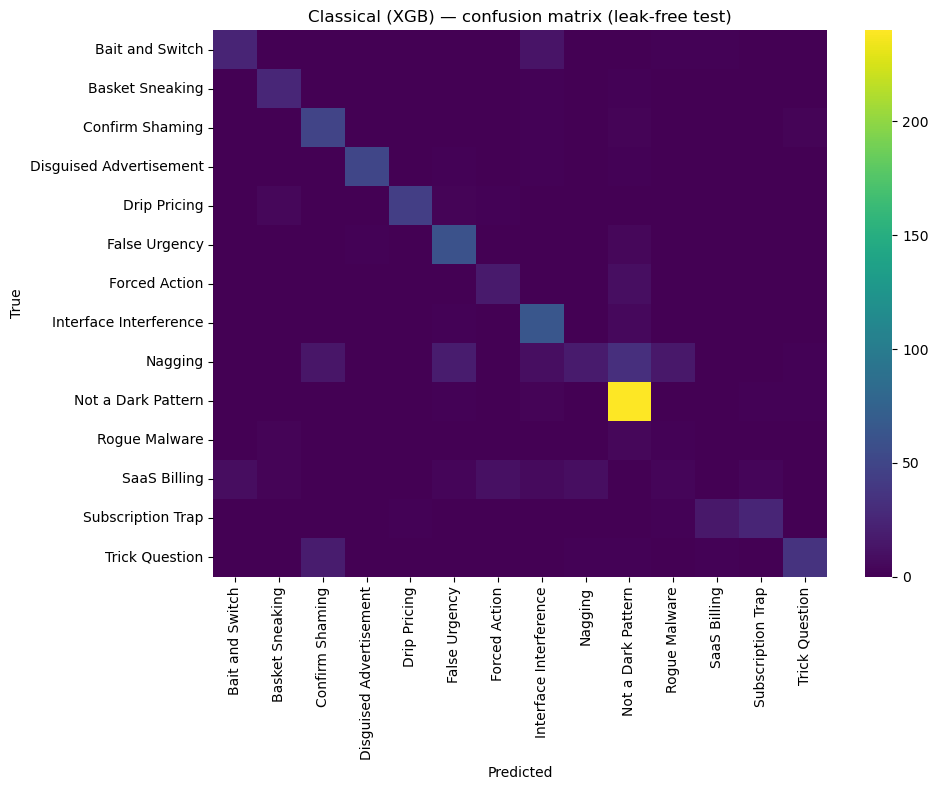

                         precision    recall  f1-score   support

        Bait and Switch       0.75      0.62      0.68        39
        Basket Sneaking       0.76      0.93      0.84        28
        Confirm Shaming       0.60      0.91      0.72        53
Disguised Advertisement       0.98      0.94      0.96        53
           Drip Pricing       0.98      0.86      0.92        51
          False Urgency       0.70      0.92      0.79        65
          Forced Action       0.59      0.64      0.62        25
 Interface Interference       0.66      0.91      0.77        70
                Nagging       0.63      0.16      0.26       106
     Not a Dark Pattern       0.80      0.98      0.88       245
          Rogue Malware       0.05      0.14      0.07         7
           SaaS Billing       0.00      0.00      0.00        44
      Subscription Trap       0.86      0.60      0.70        42
         Trick Question       0.90      0.62      0.74        56

               accuracy

In [13]:
best_name = 'Classical (XGB)'
cm = confusion_matrix(y_test, classical_pipes[best_name].predict(X_test_c))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='viridis', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'{best_name} — confusion matrix (leak-free test)')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()

print(classification_report(y_test, classical_pipes[best_name].predict(X_test_c),
                            target_names=CLASSES, zero_division=0))

## 11. Saving the DistilBERT Artifact (run after fine-tuning)

When `RUN_BERT=True` has produced a trained model, this saves an **inference** artifact (the
model + tokenizer + label map), not the training scaffolding — that's what the Streamlit app
will load. Gated the same way so a plain execute doesn't error.

In [14]:
if 'bert' in globals():
    import os
    out = '../models/distilbert_darkpattern'
    os.makedirs(out, exist_ok=True)
    globals()['bert'].save_pretrained(out)
    globals()['tok'].save_pretrained(out)
    with open(os.path.join(out, 'label_map.json'), 'w') as f:
        json.dump({'classes': CLASSES, 'max_length': 64}, f, indent=2)
    print('saved DistilBERT inference artifact ->', out)
else:
    print("nothing to save yet — train DistilBERT (cell 7) first.")

nothing to save yet — train DistilBERT (cell 7) first.
